# CalMS21 end-to-end template

notebook to process CalMS21 data: index raw tracks, convert to standard format, compute features (pair distances/ego, wavelets, global t-SNE), cluster (KMeans/Ward), evaluate against ground truth, and train a local XGBoost behavior model. Fill in the paths/run_ids for your machine.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mosaic.behavior.feature_library import (
    GlobalKMeansClustering,
    GlobalTSNE,
    GlobalWardClustering,
    GroundTruthLabelsSource,
    Inputs,
    ResultColumn,
    ModelPredictFeature,
    PairEgocentricFeatures,
    PairPoseDistancePCA,
    PairWavelet,
    TemporalStackingFeature,
    WardAssignClustering,
)
from mosaic.behavior.model_library import BehaviorXGBoostModel
from mosaic.behavior.visualization_library import VizGlobalColored
from mosaic.core.analysis import compute_cluster_label_agreement
from mosaic.core.dataset import BEHAVIOR_LABEL_MAP, Dataset

# BEHAVIOR_LABEL_MAP  # note that this is currently hard coded for the calms21 dataset

## Dataset setup

In [2]:
DATA_ROOT = Path("/home/paul/ecodylic/minimal_calms21/")

manifest_path = DATA_ROOT / "dataset.yaml"
dataset = Dataset(manifest_path).load()

In [3]:
dataset

Dataset(manifest_path=PosixPath('/home/paul/ecodylic/minimal_calms21/dataset.yaml'), name='calms21-minimal', version='0.1.0', format='yaml', roots={'media': 'videos', 'tracks': 'tracks', 'frames': 'frames', 'features': 'features', 'labels': 'labels', 'models': '/home/paul/ecodylic/minimal_calms21/models'}, meta={}, dataset_type='discrete', segment_duration=None, time_column=None)

## Core feature pipeline (CalMS21)

In [4]:
GROUP_SCOPE = None  # used to define scope_filter during dataset.run_feature
# similarly, SEQUENCE_SCOPE could be defined and passed to sequences=...

In [5]:
# Pair pose distance PCA (social distances)

feat_pose = PairPoseDistancePCA(params={"n_components": 6, "pose": {"pose_n": 7}})
pose_result = dataset.run_feature(feat_pose, groups=GROUP_SCOPE)
print(pose_result)

[feature:pair-posedistance-pca] completed run_id=0.1-ac571236a2 -> /home/paul/ecodylic/minimal_calms21/features/pair-posedistance-pca/0.1-ac571236a2
Result(feature='pair-posedistance-pca', run_id='0.1-ac571236a2')


[feature:pair-posedistance-pca] fit phase skipped (overwrite=False, outputs exist)


In [6]:
# features that only accept track input have that as a default: inputs=Inputs(('tracks',))
# note that inputs only accepts a Sequence (tuple or list), e.g.:
# Inputs(["tracks"]) or Inputs(("tracks",))
# Inputs([feature_result1, feature_result2, ...]) or same as tuple
# can also be mixed with tracks

# some features only allow empty inputs
# Inputs(())
# all other features will reject empty inputs

# the result of a feature run is now a small dataclass that has the derived feature name
# with __from__ suffixes if reuses other feature, or the "feature1+feature2" for multiple features (formerly inputsets)

# so pose_result.feature -> feature name (same as directory)
# pose_result.run_id -> run_id (subdirectory), hash includes inputs and all their (recursive) dependencies through their own run_id hash, and scope_filter

In [7]:
# Pair egocentric kinematics

feat_ego = PairEgocentricFeatures(params={"neck_idx": 3, "tail_base_idx": 6})
ego_result = dataset.run_feature(
    feat_ego, groups=GROUP_SCOPE, parallel_workers=4, parallel_mode="process"
)
print(ego_result)

[feature:pair-egocentric] completed run_id=0.1-986fda1b7a -> /home/paul/ecodylic/minimal_calms21/features/pair-egocentric/0.1-986fda1b7a
Result(feature='pair-egocentric', run_id='0.1-986fda1b7a')


In [8]:
## wavelet transformations

wavelet_params = {
    "f_min": 0.2,
    "f_max": 5.0,
    "n_freq": 25,
    "wavelet": "cmor1.5-1.0",
    "log_floor": -3.0,
    "sampling": {"fps_default": 30.0},
}

# Wavelets on PCA (social)
feat_wave_social = PairWavelet(Inputs((pose_result,)), params=wavelet_params)
social_wave_result = dataset.run_feature(
    feat_wave_social, groups=GROUP_SCOPE, parallel_workers=4, parallel_mode="process"
)
print(social_wave_result)

# Wavelets on egocentric (ego)
feat_wave_ego = PairWavelet(Inputs((ego_result,)), params=wavelet_params)
ego_wave_result = dataset.run_feature(
    feat_wave_ego, groups=GROUP_SCOPE, parallel_workers=4, parallel_mode="process"
)
print(ego_wave_result)

[feature:pair-wavelet__from__pair-posedistance-pca] completed run_id=0.1-dce7dfaa22 -> /home/paul/ecodylic/minimal_calms21/features/pair-wavelet__from__pair-posedistance-pca/0.1-dce7dfaa22
Result(feature='pair-wavelet__from__pair-posedistance-pca', run_id='0.1-dce7dfaa22')
[feature:pair-wavelet__from__pair-egocentric] completed run_id=0.1-ae754da383 -> /home/paul/ecodylic/minimal_calms21/features/pair-wavelet__from__pair-egocentric/0.1-ae754da383
Result(feature='pair-wavelet__from__pair-egocentric', run_id='0.1-ae754da383')


In [9]:
# note, you could also use_latest instead, which returns a new result with run_id set to None
# this then retrieves the last run for this feature (same behavior as before)

# Inputs((pose_result.use_latest(),))

## Global embedding and clustering

In [10]:
# Global t-SNE over multiple features (formerly used inputset)

tsne = GlobalTSNE(
    Inputs((social_wave_result, ego_wave_result)),
    params={
        "total_templates": 2000,
        "perplexity": 50,
    },
)
tsne_result = dataset.run_feature(tsne, groups=GROUP_SCOPE)
print(tsne_result)

[feature:global-tsne__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.3-c827909de9 -> /home/paul/ecodylic/minimal_calms21/features/global-tsne__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.3-c827909de9
Result(feature='global-tsne__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric', run_id='0.3-c827909de9')


[feature:global-tsne] fit phase skipped (overwrite=False, outputs exist)


In [11]:
# k-means below uses the same features (could also define as variable once and reuse)

# also note that each feature now needs to define its "artifacts" that are written to disk but are not per-frame outputs
# these are defined as dataclasses within the feature class body, and implement a from_result() to directly retrieve from a previous feature run

kmeans_results = []
for k in [50, 100]:
    kmeans = GlobalKMeansClustering(
        Inputs((social_wave_result, ego_wave_result)),
        params={
            "k": int(k),
            "templates": GlobalTSNE.TemplatesArtifact.from_result(tsne_result),  # specify artifact loading mechanism, implemented by feature that writes artifact
            "label_artifact_points": True,
            "scaler": GlobalTSNE.ScalerArtifact.from_result(tsne_result),
        },
    )
    k_result = dataset.run_feature(kmeans, groups=GROUP_SCOPE)
    kmeans_results.append({"k": int(k), "run": k_result})
    print(k_result)

[feature:global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.4-db770c9073 -> /home/paul/ecodylic/minimal_calms21/features/global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.4-db770c9073
Result(feature='global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric', run_id='0.4-db770c9073')
[feature:global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.4-8cfe0a166a -> /home/paul/ecodylic/minimal_calms21/features/global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.4-8cfe0a166a
Result(feature='global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric', run_id='0.4-8cfe0a166a')


[feature:global-kmeans] fit phase skipped (overwrite=False, outputs exist)
[feature:global-kmeans] fit phase skipped (overwrite=False, outputs exist)


Tip: `kmeans_results` holds multiple runs; select a specific `run_id` (e.g., `kmeans_results[0]['run'].run_id`) when you need a stable reference.


In [12]:
# ward clustering allows no per-frame inputs (tracks or other feature), instead it reads tsne templates artifact directly
# inputs default to Inputs(())  # empty tuple

ward = GlobalWardClustering(
    params={
        "templates": GlobalTSNE.TemplatesArtifact.from_result(tsne_result),
        "method": "ward",
    }
)
ward_result = dataset.run_feature(ward, groups=GROUP_SCOPE)
print(ward_result)

[feature:global-ward] completed run_id=0.2-74e35841b7 -> /home/paul/ecodylic/minimal_calms21/features/global-ward/0.2-74e35841b7
Result(feature='global-ward', run_id='0.2-74e35841b7')


[feature:global-ward] fit phase skipped (overwrite=False, outputs exist)


In [13]:
ward_assign_results = []
for cut in [25, 50, 100]:
    assign = WardAssignClustering(
        Inputs((social_wave_result, ego_wave_result)),  # reuse same inputs from before
        params={
            "ward": GlobalWardClustering.ModelArtifact.from_result(ward_result),
            "templates": GlobalTSNE.TemplatesArtifact.from_result(tsne_result),
            "scaler": GlobalTSNE.ScalerArtifact.from_result(tsne_result),
            "n_clusters": int(cut),
            "recalc": False,
        },
    )
    assign_result = dataset.run_feature(assign, groups=GROUP_SCOPE, parallel_workers=3)
    ward_assign_results.append({"n_clusters": int(cut), "run": assign_result})

[feature:ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.2-031f5826e0 -> /home/paul/ecodylic/minimal_calms21/features/ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.2-031f5826e0
[feature:ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.2-86cf26f3e5 -> /home/paul/ecodylic/minimal_calms21/features/ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.2-86cf26f3e5
[feature:ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric] completed run_id=0.2-f8a5755ca8 -> /home/paul/ecodylic/minimal_calms21/features/ward-assign__from__global-ward__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric/0.2-

[feature:ward-assign] fit phase skipped (overwrite=False, outputs exist)
[feature:ward-assign] fit phase skipped (overwrite=False, outputs exist)
[feature:ward-assign] fit phase skipped (overwrite=False, outputs exist)


In [17]:
import pandas as pd

In [25]:
pd.DataFrame(np.arange(100).reshape(10, 10)).drop(columns=set([1, 2, 11]) & set(range(10)))

,0,3,4,5,6,7,8,9
0,0,3,4,5,6,7,8,9
1,10,13,14,15,16,17,18,19
2,20,23,24,25,26,27,28,29
3,30,33,34,35,36,37,38,39
4,40,43,44,45,46,47,48,49
5,50,53,54,55,56,57,58,59
6,60,63,64,65,66,67,68,69
7,70,73,74,75,76,77,78,79
8,80,83,84,85,86,87,88,89
9,90,93,94,95,96,97,98,99


## Cluster/label agreement (GT vs clusters)

Exploratory data analysis step

In [48]:
from dataclasses import dataclass

@dataclass
class A:
    a: int = 1

@dataclass
class B:
    b: int = 2

a = A()
b = B()

def build_set():
    global a, b
    return set([a.a, b.b])

a = A(a=10)

build_set()

{2, 10}

In [14]:
kmeans_feature = k_result.feature
run_id = k_result.run_id

agr = compute_cluster_label_agreement(
    dataset,
    cluster_feature=kmeans_feature,
    cluster_run_id=run_id,
    label_kind="behavior",
    sequences=None,
)
agr

{'cluster_feature': 'global-kmeans__from__pair-wavelet__from__pair-posedistance-pca+pair-wavelet__from__pair-egocentric',
 'cluster_run_id': '0.4-8cfe0a166a',
 'label_kind': 'behavior',
 'n_sequences': 4,
 'n_frames_total': 112778,
 'n_frames_used': 112778,
 'sampled': False,
 'metrics': {'n_samples': 112778,
  'n_classes': 4,
  'n_clusters': 100,
  'ARI': 0.016105999147180278,
  'AMI': 0.1554349478841699,
  'homogeneity': 0.4649687621672326,
  'completeness': 0.09363490300596461,
  'v_measure': 0.15587905221793824,
  'purity': 0.8075954530138857,
  'hungarian_accuracy': 0.05848658426288815,
  'confusion': array([[   0,   95,    0,    0, 1134,    0,   54,    0,    0,   20,   86,
           303,    0,  528,  220,    0,   96,   62,    0,    0,    0,  356,
             0,    0,  624,    0,   61,  401,   38,  469,  254,    0, 1573,
            82,  288,    0,    0,    0,    0,  133,    0,    0,    0,    0,
            30,    0,    0,  197,    0,    0,    0,   56,  432,    0,    0,
        

## Visualizations (GT + clusters on t-SNE)

[viz-global-colored] INFO: labels shorter than coords for key=calms21_task1_test__task1%2Ftest%2Fmouse075_task1_annotator1 (18015 vs 36030); repeating labels x2
[viz-global-colored] INFO: labels shorter than coords for key=calms21_task1_test__task1%2Ftest%2Fmouse076_task1_annotator1 (19710 vs 39420); repeating labels x2
[viz-global-colored] INFO: labels shorter than coords for key=calms21_task1_train__task1%2Ftrain%2Fmouse018_task1_annotator1 (6127 vs 12254); repeating labels x2
[viz-global-colored] INFO: labels shorter than coords for key=calms21_task1_train__task1%2Ftrain%2Fmouse070_task1_annotator1 (12537 vs 25074); repeating labels x2


[feature:viz-global-colored] completed run_id=0.1-ce1b469ca1 -> /home/paul/ecodylic/minimal_calms21/features/viz-global-colored/0.1-ce1b469ca1
Result(feature='viz-global-colored', run_id='0.1-ce1b469ca1')


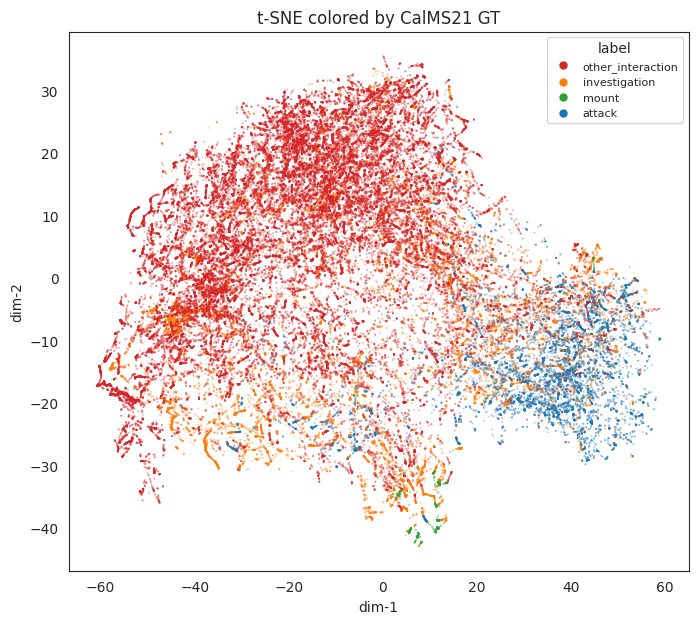

In [15]:
# visualization features also follow the new feature/artifact input

viz_gt = VizGlobalColored(
    params={
        "x": ResultColumn(column="tsne_x").from_result(tsne_result),
        "y": ResultColumn(column="tsne_y").from_result(tsne_result),
        "labels": GroundTruthLabelsSource(),  # load dataset default ground truth labels
        "title": "t-SNE colored by CalMS21 GT",
        "label_order": list(BEHAVIOR_LABEL_MAP.keys()),
        "label_name_map": BEHAVIOR_LABEL_MAP,
        "palette": sns.color_palette("tab10", len(BEHAVIOR_LABEL_MAP)),
    }
)
viz_gt_result = dataset.run_feature(viz_gt, groups=GROUP_SCOPE, overwrite=True)
print(viz_gt_result)

[feature:viz-global-colored] completed run_id=0.1-b0399be1d3 -> /home/paul/ecodylic/minimal_calms21/features/viz-global-colored/0.1-b0399be1d3
Result(feature='viz-global-colored', run_id='0.1-b0399be1d3')


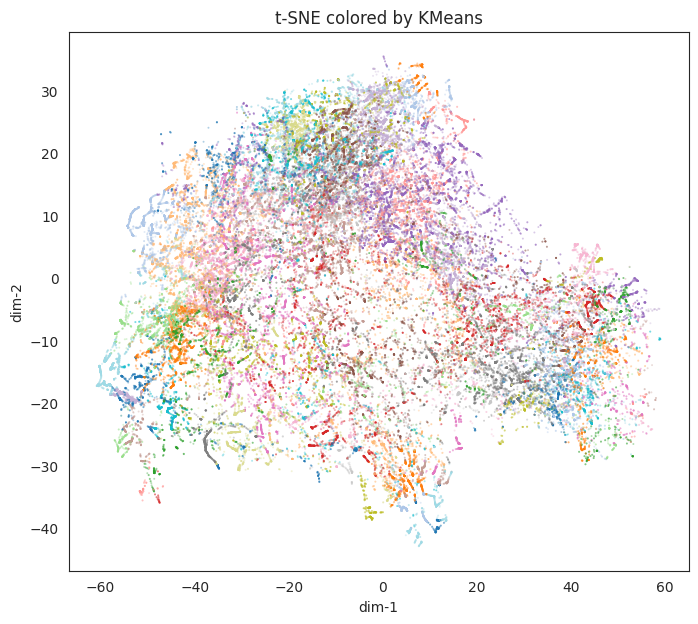

In [16]:
viz_km = VizGlobalColored(
    params={
        "x": ResultColumn(column="tsne_x").from_result(tsne_result),
        "y": ResultColumn(column="tsne_y").from_result(tsne_result),
        "labels": ResultColumn(column="cluster").from_result(k_result),
        "title": "t-SNE colored by KMeans",
    }
)
viz_km_result = dataset.run_feature(viz_km, groups=GROUP_SCOPE, overwrite=True)
print(viz_km_result)

## Model training (local XGBoost)

### Temporal stack feature for model input

In [17]:
# Smoke test: slicing to a small subset; remove the slices for full training
# Build explicit splits
train_seqs = [s for s in dataset.list_sequences() if "task1/train" in s]
test_seqs = [s for s in dataset.list_sequences() if "task1/test" in s]


# # minimal calms21 is small, anyways (only two sequences per train/test)

# # for a test fit, just key a subset (remove this to fit on full dataset)
# train_seqs = train_seqs[3:4]
# test_seqs = test_seqs[3:4]

In [ ]:
# Temporal stack over wavelet features
ts_stack = TemporalStackingFeature(
    Inputs((social_wave_result, ego_wave_result)),
    params={
        "half": 2,
        "skip": 1,
        "use_temporal_stack": True,
        "sigma_stack": 2,
        "add_pool": False,
        "pool_stats": ("mean",),
        "fps": 30.0,
    },
)
ts_stack_result = dataset.run_feature(
    ts_stack,
    groups=GROUP_SCOPE,
    sequences=(train_seqs + test_seqs),  # explicitely uses all sequences as scope_filter here
    parallel_workers=4,
    parallel_mode="thread",
)
print(ts_stack_result)

### Fit model using feature as input

In [19]:
dataset.set_root("models", DATA_ROOT / "models")
dataset.save()

In [ ]:
# model is not a feature that can be used with run_feature (yet), so not much changes here

xgb_model = BehaviorXGBoostModel()
xgb_model.bind_dataset(dataset)

run_root = dataset.get_root("models") / xgb_model.name / "calms21-local"
run_root.mkdir(parents=True, exist_ok=True)

xgb_config = {
    "feature": ts_stack_result.feature,
    "feature_run_id": ts_stack_result.run_id,
    "label_kind": "behavior",
    "train_sequences": train_seqs,
    "test_sequences": test_seqs,
    "random_state": 43,
    "classes": [0, 1, 2, 3],
    "label_map": {0: "attack", 1: "investigation", 2: "mount", 3: "other"},
    "standardize": True,
    "foreground_samples": 500,  # added this to be able to run locally on a laptop, max samples to use of foreground category
    "undersample_ratio": 3.0,
    "use_smote": False,
    "xgb_params": {"n_estimators": 10, "device": "cpu"},  # very short fit
    "use_external_memory": False,
}

xgb_model.configure(xgb_config, run_root)
train_summary = xgb_model.train()
json.dump(train_summary, open(run_root / "train_summary.json", "w"), indent=2)
train_summary

In [21]:
# Verify model outputs exist
print("model run root:", run_root)
print("models present:", (run_root / "models.joblib").exists())

model run root: /home/paul/ecodylic/minimal_calms21/models/behavior-xgb/calms21-local
models present: True


In [22]:
# 1) Quick per-class metrics table
summary_df = pd.read_csv(run_root / "summary.csv")
display(summary_df.sort_values("behavior"))

# 2) Full reports + confusion matrices
with open(run_root / "reports.json") as f:
    reports = json.load(f)

conf_mats = {
    int(cls): np.array(payload["confusion_matrix"]) for cls, payload in reports.items()
}

# for cls, cm in conf_mats.items():
#     print(f"\nBehavior {cls} confusion matrix (rows=true, cols=pred):")
#     display(pd.DataFrame(cm, index=["neg", "pos"], columns=["neg", "pos"]))

macro_f1 = np.mean(
    [payload["report"][str(cls)]["f1-score"] for cls, payload in reports.items()]
)
print(f"Macro F1: {macro_f1:.3f}")

,behavior,precision,recall,f1,support,average_precision
0,0,0.899110,0.028907,0.056013,10482.0,0.747950
1,1,0.030303,0.000405,0.000800,9866.0,0.202559
2,2,0.000000,0.000000,0.000000,66.0,0.000875
3,3,0.732117,0.999764,0.845259,55036.0,0.917639


Macro F1: 0.226


### Predict using feature

In [ ]:
# Predict back onto temporal-stack features

predict_feat = ModelPredictFeature(
    Inputs((ts_stack_result,)),  # reuse same features as for model fit
    params={
        "model_class": "mosaic.behavior.model_library.behavior_xgboost.BehaviorXGBoostModel",
        "model_run_id": "calms21-local",
        "model_name": xgb_model.name,
        "output_feature_name": f"{xgb_model.name}-pred",
    },
)
pred_result = dataset.run_feature(predict_feat, groups=GROUP_SCOPE)
print(pred_result)

### Other method: create inputset and train model on inputset
Here, this does the same fits, because the inputset only contains one feature.  

Note that could also train the model directly on the social+ego input, i.e. without temporal stacking

In [ ]:
# this is fully supported already, just use Inputs((social_wave_result, ego_wave_result)) instead

# BUT, since XGBoostModel is not a feature, we can't yet set scope_filter that should handle
# sequences (currently manual selection)
# time thresholds (time or frame based for start and end) - those are currently handled in the run_feature(..., scope_filter) argument